In [16]:
# First: we need to generate dataset
import numpy as np
import matplotlib.pyplot as plt

def clum(k, N, nmin):
    """
    Генерирует k размеров кластеров, сумма которых равна N;
    каждый размер не меньше nmin (шаг 1 алгоритма).
    """
    N_rem = N - k * nmin
    if N_rem < 0:
        raise ValueError(f"N={N} слишком мало для k={k} кластеров размером nmin={nmin}.")
    if N_rem == 0:
        return np.full(k, nmin, dtype=int)

    n0 = np.random.randint(1, N_rem + 1, size=k - 1)
    n0 = np.append(n0, N_rem)
    dd = np.sort(n0)[::-1]

    Nk = np.empty(k, dtype=int)
    Nk[:-1] = dd[:-1] - dd[1:]
    Nk[-1] = dd[-1]
    Nk = Nk + nmin
    return Nk


def generate_clusters(N, V, K, n_min, alpha, seed=None, verbouse = False):
    """
    Генерация синтетических данных

    Параметры

    N     : int   - общее число сущностей (объектов)
    V     : int   - число признаков (размерность пространства)
    K     : int   - число кластеров (K* в описании)
    n_min : int   - минимальный размер кластера (n в описании)
    alpha : float - параметр "смешивания" кластеров, 0 < alpha < 1
                   (чем больше alpha, тем ближе центры)
    seed  : int   - зерно ГСЧ для воспроизводимости 

    Return
    
    Y      : ndarray формы (N, V) - матрица данных
    labels : ndarray формы (N,)   - скрытые метки кластеров (1..K)
    centers: ndarray формы (K, V) - сгенерированные центры кластеров
    Nk     : ndarray формы (K,)   - размеры каждого кластера
    """
    if seed is not None:
        np.random.seed(seed)

    # Проверка условия K* * n < N
    if K * n_min >= N:
        raise ValueError(
            f"Условие K*n < N нарушено: {K}*{n_min} = {K*n_min} >= {N}. "
            "Уменьшите K или n_min, либо увеличьте N."
        )
    if not (0 < alpha < 1):
        raise ValueError("Параметр alpha должен лежать в интервале (0, 1).")

    Nk = clum(K, N, n_min)
    if verbouse:
        print(f"Размеры кластеров Nk = {Nk}, сумма = {Nk.sum()}")

    low, high = alpha - 1.0, 1.0 - alpha
    centers = np.random.uniform(low, high, size=(K, V))
    if verbouse:
        print(f"Центры сгенерированы на интервале ({low:.2f}, {high:.2f})")

    Y_blocks = []
    for k in range(K):
        sk = np.random.uniform(0.05, 0.10, size=V)

        noise = np.random.normal(loc=0.0, scale=sk, size=(Nk[k], V))

        Yk = centers[k] + noise
        Y_blocks.append(Yk)

    Y = np.vstack(Y_blocks)                        # (N, V)
    labels = np.repeat(np.arange(1, K + 1), Nk)    # (N,)
    if verbouse:
        print(f" Итоговая матрица Y имеет форму {Y.shape}")
    return Y, labels, centers, Nk


In [17]:
#Second we need functions to run Kmeans, Kmeans_inertion and the main part is Custom_kmeans
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.cluster import kmeans_plusplus

def custom_kmeans_with_inertia(X, n_clusters, epsilon=0.5, max_iter=300, tol=1e-4, 
                                random_state=None, init='k-means++'):
    """
    Модифицированный K-means с инерцией в обновлении центров.
    
    Новый центр = epsilon * C_k + (1 - epsilon) * C'_k
    
    Параметры:
    -----------
    X : ndarray формы (n_samples, n_features)
        Данные для кластеризации
    n_clusters : int
        Количество кластеров
    epsilon : float, default=0.5
        Параметр сглаживания (0 <= epsilon <= 1)
        - epsilon = 0: классический K-means
        - epsilon > 0: центры плавнее сдвигаются к центрам масс
    max_iter : int, default=300
        Максимальное количество итераций
    tol : float, default=1e-4
        Порог сходимости
    random_state : int or None, default=None
        Зерно для воспроизводимости
    init : str, default='k-means++'
        Метод инициализации ('k-means++' или 'random')
    
    Возвращает:
    -----------
    centers : ndarray формы (n_clusters, n_features)
        Финальные центры кластеров
    labels : ndarray формы (n_samples,)
        Метки кластеров для каждой точки
    inertia : float
        Сумма квадратов расстояний до ближайшего центра
    n_iter : int
        Количество итераций до сходимости
    """
    if not (0 <= epsilon <= 1):
        raise ValueError("epsilon is not in interval [0, 1]")
    
    n_samples, n_features = X.shape
    rng = np.random.RandomState(random_state)
    
    if init == 'k-means++':
        centers, _ = kmeans_plusplus(X, n_clusters, random_state=rng)
    elif init == 'random':
        indices = rng.choice(n_samples, n_clusters, replace=False)
        centers = X[indices]
    else:
        raise ValueError("init должен быть 'k-means++' или 'random'")
    
    labels = np.zeros(n_samples, dtype=np.int32)
    
    for iteration in range(max_iter):
        distances = np.linalg.norm(X[:, np.newaxis] - centers, axis=2)
        labels = np.argmin(distances, axis=1)
        
        new_centroids = np.zeros_like(centers)
        for k in range(n_clusters):
            cluster_points = X[labels == k]
            if len(cluster_points) > 0:
                new_centroids[k] = cluster_points.mean(axis=0)
            else:
                new_centroids[k] = centers[k]
        
        # new_center = epsilon * old_center + (1 - epsilon) * centroid
        old_centers = centers.copy()
        centers = epsilon * old_centers + (1 - epsilon) * new_centroids
        
        center_shift = np.linalg.norm(centers - old_centers)
        if center_shift < tol:
            break
    
    distances = np.linalg.norm(X[:, np.newaxis] - centers, axis=2)
    labels = np.argmin(distances, axis=1)
    inertia = np.sum(np.min(distances, axis=1) ** 2)
    
    return centers, labels, inertia, iteration + 1

def test_kmeans(Y, true_labels, K, random_state=42):
    kmeans = KMeans(n_clusters=K, init='k-means++', n_init=1, random_state=random_state) #important to n_init = 1
    pred_labels = kmeans.fit_predict(Y)
    n_iter = kmeans.n_iter_

    sil_score = silhouette_score(Y, pred_labels)
    ari_score = adjusted_rand_score(true_labels, pred_labels)
    
    return pred_labels, kmeans.cluster_centers_, n_iter, sil_score, ari_score



def test_custom_kmeans(Y, true_labels, K, epsilon=0.5, random_state=42):
    """
    Применяет модифицированный K-means и вычисляет метрики.
    """
    centers, pred_labels, inertia, n_iter = custom_kmeans_with_inertia(
        Y, n_clusters=K, epsilon=epsilon, random_state=random_state
    )
    
    sil_score = silhouette_score(Y, pred_labels)
    ari_score = adjusted_rand_score(true_labels, pred_labels)
    
    return pred_labels, centers,  n_iter, sil_score, ari_score




In [18]:
#We start experiment for dataset and chosen version of algorithm
def run_single_experiment(alpha, seed, N, V, K, n_min, exp_name, epsilon=0.5, init = 'custom'):
    """
    Запускает один эксперимент с модифицированным K-means.
    """
    if init == 'custom':
        print(f"{exp_name}: alpha = {alpha}, epsilon = {epsilon}")

        Y, true_labels, centers, _ = generate_clusters(N, V, K, n_min, alpha, seed)
        pred_labels, km_centers, n_iter, sil, ari = test_custom_kmeans(
            Y, true_labels, K, epsilon=epsilon
        )

        print(f"Silhouette Score: {sil:.4f}")
        print(f"ARI:              {ari:.4f}")
        print(f"Итераций:         {n_iter}\n")

        return {
            'Y': Y,
            'true_labels': true_labels,
            'centers': centers,
            'pred_labels': pred_labels,
            'km_centers': km_centers,
            'sil': sil,
            'ari': ari,
            'alpha': alpha,
            'epsilon': epsilon,
            'n_iter': n_iter,
            'exp_name': exp_name
        }
    elif init == 'basic':
        print(f"{exp_name}: alpha = {alpha}")

        Y, true_labels, centers, _ = generate_clusters(N, V, K, n_min, alpha, seed)
        pred_labels, km_centers, n_iter, sil, ari = test_kmeans(Y, true_labels, K)

        print(f"Silhouette Score: {sil:.4f}")
        print(f"ARI:              {ari:.4f}")
        print(f"Итераций:         {n_iter}\n")


        return {
            'Y': Y,
            'true_labels': true_labels,
            'centers': centers,
            'pred_labels': pred_labels,
            'km_centers': km_centers,
            'sil': sil,
            'ari': ari,
            'alpha': alpha,
            'n_iter': n_iter,
            'exp_name': exp_name
        }
    else:
        raise ValueError("init должен быть 'custom' или 'basic'")


In [19]:
#now we visualize results for first two dimensions

def visualize_experiment_b(exp_data):
    """
    Visualize for KMeans from sclearn
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    axes[0].scatter(exp_data['Y'][:, 0], exp_data['Y'][:, 1], 
                    c=exp_data['true_labels'], cmap='viridis', s=15, alpha=0.7)
    axes[0].scatter(exp_data['centers'][:, 0], exp_data['centers'][:, 1], 
                    c='red', marker='X', s=150, edgecolor='black', label='Истинные центры')
    axes[0].set_title(f"{exp_data['exp_name']}: Истинные метки (α={exp_data['alpha']})")
    axes[0].set_xticks([])
    axes[0].set_yticks([])
    axes[0].legend(loc='upper right')
    
    axes[1].scatter(exp_data['Y'][:, 0], exp_data['Y'][:, 1], 
                    c=exp_data['pred_labels'], cmap='viridis', s=15, alpha=0.7)
    axes[1].scatter(exp_data['km_centers'][:, 0], exp_data['km_centers'][:, 1], 
                    c='red', marker='X', s=150, edgecolor='black', label='Центры K-Means')
    axes[1].set_title(f"{exp_data['exp_name']}: K-Means (Sil={exp_data['sil']:.2f}, ARI={exp_data['ari']:.2f}, iter={exp_data['n_iter']})")
    axes[1].set_xticks([])
    axes[1].set_yticks([])
    axes[1].legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

In [20]:
def visualize_experiment_c(exp_data):
    """
    Visualization for custom KMeans
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    axes[0].scatter(exp_data['Y'][:, 0], exp_data['Y'][:, 1], 
                    c=exp_data['true_labels'], cmap='viridis', s=15, alpha=0.7)
    axes[0].scatter(exp_data['centers'][:, 0], exp_data['centers'][:, 1], 
                    c='red', marker='X', s=150, edgecolor='black', label='Истинные центры')
    axes[0].set_title(f"{exp_data['exp_name']}: Истинные метки (α={exp_data['alpha']})")
    axes[0].set_xticks([])
    axes[0].set_yticks([])
    axes[0].legend(loc='upper right')
    
    axes[1].scatter(exp_data['Y'][:, 0], exp_data['Y'][:, 1], 
                    c=exp_data['pred_labels'], cmap='viridis', s=15, alpha=0.7)
    axes[1].scatter(exp_data['km_centers'][:, 0], exp_data['km_centers'][:, 1], 
                    c='red', marker='X', s=150, edgecolor='black', label='Центры алгоритма')
    axes[1].set_title(f"{exp_data['exp_name']}: Custom K-Means ε={exp_data['epsilon']}\n"
                      f"(Sil={exp_data['sil']:.2f}, ARI={exp_data['ari']:.2f}, iter={exp_data['n_iter']})")
    axes[1].set_xticks([])
    axes[1].set_yticks([])
    axes[1].legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()


In [21]:
#starting conditions for dataset

N = 2500     #all points
V = 15       #number of dimensions/features
K = 60       #number of clusters
n_min = 10   #at least that amount of points in each cluster

Эксп. 1 ( Basic KMean): alpha = 0.8
Silhouette Score: 0.2007
ARI:              0.7897
Итераций:         12



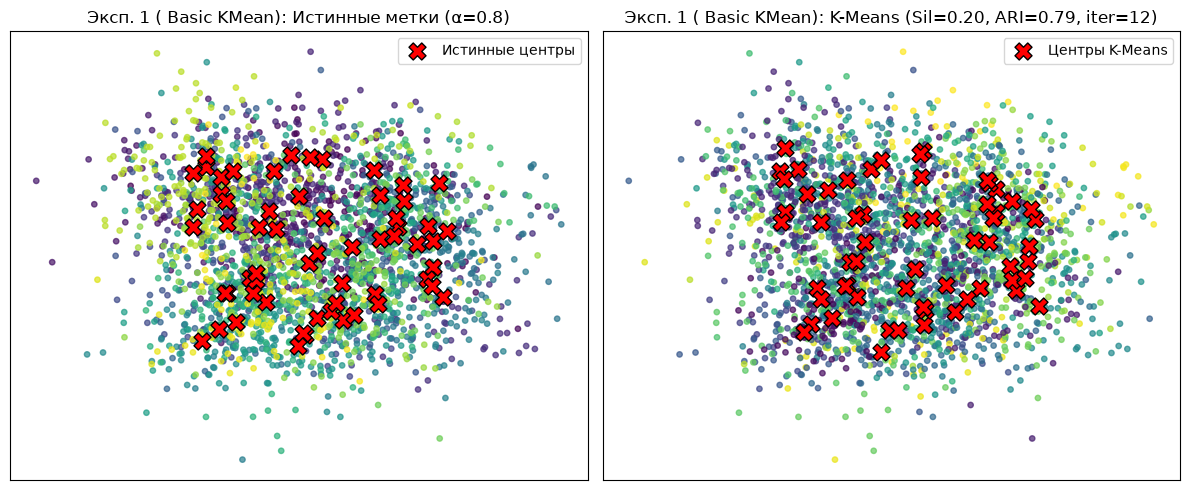

Эксп. 2 (K_Mean with inertion, ε=0.3): alpha = 0.8, epsilon = 0.3
Silhouette Score: 0.2004
ARI:              0.7879
Итераций:         22



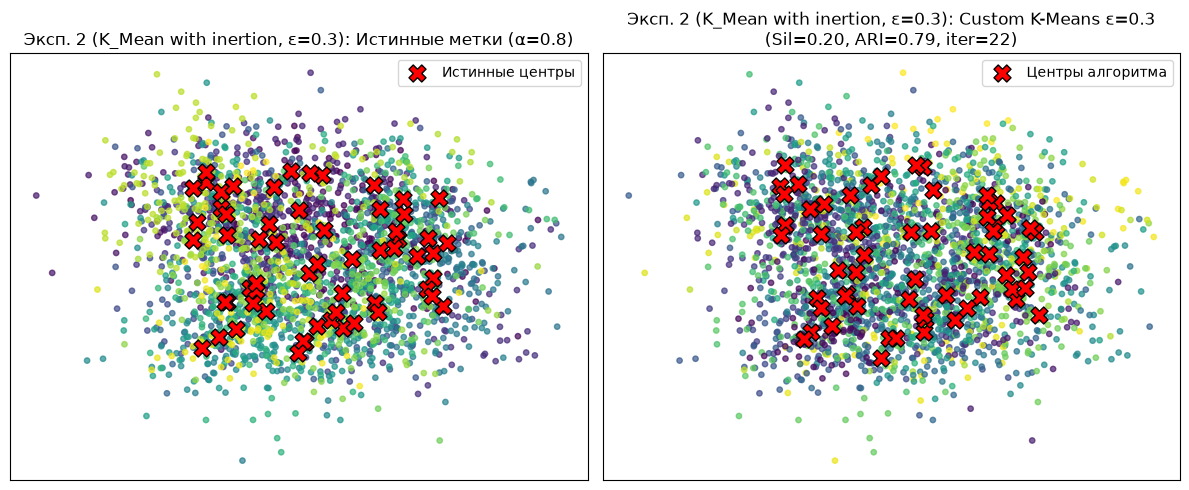

In [22]:
seed = np.random.randint(0, 2**32 - 1)
    
exp1 = run_single_experiment(alpha=0.8, seed=seed, N=N, V=V, K=K, n_min=n_min, 
                                exp_name="Эксп. 1 ( Basic KMean)", init = 'basic')
visualize_experiment_b(exp1)

exp2 = run_single_experiment(alpha=0.8, seed=seed, N=N, V=V, K=K, n_min=n_min, 
                                exp_name="Эксп. 2 (K_Mean with inertion, ε=0.3)", epsilon=0.3)

visualize_experiment_c(exp2) 

But results depends on starting centers of clusters, so lets run more than once on one dataset

In [23]:
import time
import pandas as pd

def _to_list(x):
    if x is None:
        return None
    if isinstance(x, (list, tuple, np.ndarray)):
        return list(x)
    return [x]


def run_experiment(
    N=2500,
    n_min=100,
    n_runs=30,
    V_list=15,
    K_list=7,
    alpha_list=0.5,
    epsilon_list=0.1,
):
    """
    Запускает эксперимент по сравнению стандартного K-Means и K-Means с инерцией.

    Параметры могут быть переданы как массивы (списки) или как одиночные числа/скаляры —
    в последнем случае они автоматически оборачиваются в список длиной 1.

    Возвращает:
        results — словарь {V: {K: {alpha: {"Standard": ..., "ε=...": ...}}}}
    """
    V_list = _to_list(V_list)
    K_list = _to_list(K_list)
    alpha_list = _to_list(alpha_list)
    epsilon_list = _to_list(epsilon_list)

    results = {V: {} for V in V_list}

    start_time = time.time()

    for V in V_list:
        for K in K_list:
            results[V][f"K={K}"] = {}

            for alpha in alpha_list:
                ari_std_list = []
                ari_eps_list = {eps: [] for eps in epsilon_list}

                for run in range(n_runs):
                    seed = V * 100000 + K * 1000 + int(alpha * 100) * 10 + run
                    Y, true_labels, _, _ = generate_clusters(
                        N, V, K, n_min, alpha, seed=seed
                    )

                    labels_std = KMeans(
                        n_clusters=K, init='k-means++', n_init=1, random_state=seed
                    ).fit_predict(Y)
                    ari_std_list.append(adjusted_rand_score(true_labels, labels_std))

                    for eps in epsilon_list:
                        _, labels_eps, _, _ = custom_kmeans_with_inertia(
                            Y, n_clusters=K, epsilon=eps, random_state=seed
                        )
                        ari_eps_list[eps].append(
                            adjusted_rand_score(true_labels, labels_eps)
                        )

                results[V][f"K={K}"][f"α={alpha}"] = {
                    "Standard": np.mean(ari_std_list),
                    **{f"ε={eps}": np.mean(ari_eps_list[eps]) for eps in epsilon_list},
                }

    print(f"Вычисления завершены за {time.time() - start_time:.1f} сек.\n")

    pd.options.display.float_format = '{:.4f}'.format

    for V in V_list:
        print(f"РЕЗУЛЬТАТЫ ARI (Adjusted Rand Index) для V = {V}")

        table_data = {"Standard": []}
        for eps in epsilon_list:
            table_data[f"ε={eps}"] = []

        columns = []
        for K in K_list:
            for alpha in alpha_list:
                columns.append((f"K={K}", f"α={alpha}"))
                res = results[V][f"K={K}"][f"α={alpha}"]
                table_data["Standard"].append(res["Standard"])
                for eps in epsilon_list:
                    table_data[f"ε={eps}"].append(res[f"ε={eps}"])

        df = pd.DataFrame(
            table_data,
            index=pd.MultiIndex.from_tuples(columns, names=["Истинное K", "Параметр α"]),
        )
        df = df.T
        print(df.to_string())
        print("\n")

    return results

In [25]:
res = run_experiment(
    N=2500, n_min=100, n_runs=30,
    V_list=[15, 50],
    K_list=[7, 15, 21],
    alpha_list=[0.5, 0.75, 0.85],
    epsilon_list=[0.1, 0.2, 0.3, 0.4, 0.6],
)

Вычисления завершены за 65.0 сек.

РЕЗУЛЬТАТЫ ARI (Adjusted Rand Index) для V = 15
Истинное K    K=7                 K=15                 K=21              
Параметр α  α=0.5 α=0.75 α=0.85  α=0.5 α=0.75 α=0.85  α=0.5 α=0.75 α=0.85
Standard   0.9514 0.9191 0.8075 0.9788 0.9244 0.8485 0.9701 0.9332 0.8322
ε=0.1      0.9514 0.9190 0.8157 0.9787 0.9250 0.8491 0.9701 0.9332 0.8344
ε=0.2      0.9514 0.9191 0.8155 0.9788 0.9246 0.8483 0.9701 0.9332 0.8328
ε=0.3      0.9514 0.9190 0.8156 0.9787 0.9247 0.8483 0.9702 0.9332 0.8348
ε=0.4      0.9514 0.9190 0.8155 0.9788 0.9223 0.8472 0.9702 0.9332 0.8289
ε=0.6      0.9514 0.9191 0.8155 0.9788 0.9223 0.8509 0.9702 0.9332 0.8290


РЕЗУЛЬТАТЫ ARI (Adjusted Rand Index) для V = 50
Истинное K    K=7                 K=15                 K=21              
Параметр α  α=0.5 α=0.75 α=0.85  α=0.5 α=0.75 α=0.85  α=0.5 α=0.75 α=0.85
Standard   0.9824 0.9210 0.8467 0.9917 0.9487 0.8975 0.9948 0.9650 0.9356
ε=0.1      0.9823 0.9210 0.8420 0.9916 0.9488 0.9003 

In [26]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
optical_recognition_of_handwritten_digits = fetch_ucirepo(id=80) 
  
# data (as pandas dataframes) 
X = optical_recognition_of_handwritten_digits.data.features 
y = optical_recognition_of_handwritten_digits.data.targets 
  
# metadata 
print(optical_recognition_of_handwritten_digits.metadata) 
  
# variable information 
print(optical_recognition_of_handwritten_digits.variables) 


{'uci_id': 80, 'name': 'Optical Recognition of Handwritten Digits', 'repository_url': 'https://archive.ics.uci.edu/dataset/80/optical+recognition+of+handwritten+digits', 'data_url': 'https://archive.ics.uci.edu/static/public/80/data.csv', 'abstract': 'Two versions of this database available; see folder', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 5620, 'num_features': 64, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1998, 'last_updated': 'Wed Aug 23 2023', 'dataset_doi': '10.24432/C50P49', 'creators': ['E. Alpaydin', 'C. Kaynak'], 'intro_paper': {'ID': 280, 'type': 'NATIVE', 'title': 'Methods of Combining Multiple Classifiers and Their Applications to Handwritten Digit Recognition', 'authors': 'C. Kaynak', 'venue': 'MSc Thesis, Institute of Graduate Studies in Science and Engineering, 

AttributeError: 'dict' object has no attribute 'append'

In [29]:
Y, uniques = pd.factorize(y['class'])


In [35]:
i = 0.0
A = 0.0
B = 0.0
C = 0.0
for t_seed in range(0, 1000):
    A +=1
    kmeans = KMeans(
    n_clusters=10,             
    n_init=1,                  
    max_iter=300,              
    random_state=t_seed            
    )

    y_pred = kmeans.fit_predict(X.values)

    ari_score = adjusted_rand_score(Y, y_pred)
    B+=ari_score
    #print(ari_score, kmeans.n_iter_)


    _, labels_eps, _, n_iter = custom_kmeans_with_inertia(
                            X.values, n_clusters=10, epsilon=0.3, random_state=t_seed
                        )
    C+=adjusted_rand_score(Y, labels_eps)
    if(ari_score < adjusted_rand_score(Y, labels_eps)):
        i+=1
        #print(f"Seed = {t_seed}, Kmeans_std_ari = {ari_score}, Kmeans_cust_ari = {adjusted_rand_score(Y, labels_eps)} ")
    #print(adjusted_rand_score(Y, labels_eps), n_iter)
print(A, i)
print(i/A)

1000.0 322.0
0.322


In [36]:
print(B/1000)
print(C/1000)

0.645698352627511
0.6457953829765835


Now we see the result of our custom algorithm job: +0.0001 to RAI. It's something, but still 

In [37]:
df = pd.read_excel('/Users/sergey_perov/Desktop/K-means_research/s-originals/s4-groundtruth-plot.xls', header=None)
df = df.drop([0], axis=1)
print(df)
init_centers = df.iloc[:15].values

X = df.iloc[15:].values

print(f"Загружено центров: {init_centers.shape[0]}")
print(f"Загружено точек для кластеризации: {X.shape[0]}")

y_true = np.loadtxt('/Users/sergey_perov/Desktop/K-means_research/s-originals/s4-label.txt', dtype=int)

      
C = 0.0
B = 0.0
cust_im = 0.0
all_d = 0.0
for i in range(0, 30000):
    all_d += 1
    kmeans = KMeans(
        n_clusters=15,                      
        n_init=1,                  
        max_iter=300,              
        random_state=i            
    )

    y_pred = kmeans.fit_predict(X)

    ari_score_st = adjusted_rand_score(y_true, y_pred)

    B+=ari_score_st
    
    #print(f"\nAdjusted Rand Index (ARI) сравнение с txt: {ari_score}")
    _, labels_eps, _, _ = custom_kmeans_with_inertia(
                        X, n_clusters=15, epsilon=0.3, random_state=i
                    )
    
    ari_score_cus = adjusted_rand_score(y_true, labels_eps)
    
    C+=ari_score_cus
    
    if ari_score_cus > ari_score_st:
            cust_im += 1
print(cust_im, all_d)
print(cust_im / all_d)


           1       2
0     645207  747013
1     304866  695374
2     730301  429068
3     770267  571916
4     536771  514289
...      ...     ...
5010  540118  671072
5011  507453  777031
5012  569266  738385
5013  444587  878830
5014  434041  814466

[5015 rows x 2 columns]
Загружено центров: 15
Загружено точек для кластеризации: 5000
16235.0 30000.0
0.5411666666666667


In [38]:
print(B/all_d)
print(C/all_d)

0.6139511818609474
0.6158759942130283


And on that dataset 2-d, highly intermixed - we get + 0.002 - not very big, but it improved k_mean